# 토지 개발 적합도 분석: Rule-Based 점수의 예측력 검증
### 도메인 경험 기반 점수 설계 및 통계적 타당성 검증
-----------------------------------------------------

## 1. 문제 정의

시행사 재직 시 다수의 토지 후보지를 검토했지만 후보지를 선별하는 명확한 기준이 없었다.

담당자별 판단 기준이 상이하여 검토 효율성이 낮았고 유망 후보지를 놓치거나 비효율적 검토가 반복되었다.

### 1.1 실무 경험 수치

· 월 평균 부지 검토 건수 : 30건

· 토지 1건당 평균 검토 시간: 약 3일

  (등기부등본 발급 → 토지대장 → 토지이용계획원 → 현장 방문 → 주변 상권 분석 → 사업성 계산)

· 실제 매입 성공률 : 3~7% (30개 중 1~2개)

· 불발률 : 93~97% (28~29개 검토 후 제외)


현재의 토지 검토 과정은 경험과 직관에 의존하며 정량적 필터링 기준이 부재하다. 
본 분석 프로젝트는 공공데이터 기반으로 매입 적합도를 평가하고, 
도메인 경험 기반 가중치의 타당성을 통계적으로 검증하는 것을 목표로 한다.

## 2. 분석 목표

1. **Rule-Based 점수 설계**: 가격상승률 + 인구증감률 가중합
2. **Logistic Regression기반 점수의 예측력 검증**: Rule 점수 → 가격 상승 여부 예측
3. **3-Model 비교**:
   - Model A: price + pop
   - Model B: rule_score
   - Model C: price + pop + Rule

   → **Rule이 원변수의 정보를 잘 요약했는지 검증**


## 3. 공공데이터 수집

### 3.1 데이터 구성

| # | 변수 | 출처 | 수집 방법 | 기간 |
|---|------|------|-----------|------|
| 1 | 실거래가 상승률 | 국토교통부 아파트 매매 실거래가 상세 자료 | API | 2021, 2024 |
| 2 | 인구 증감률 | KOSIS 행정구역(시군구)별 주민등록세대수 | Excel | 2021.12, 2024.12 |


2020~2021년은 코로나 이후 부동산 시장이 급격히 상승하던 구간이었고,

2022년 이후는 금리 인상과 정책 변화로 시장 구조가 달라졌다.

따라서 2021년을 기준 시점으로 설정하여 구조 변화 이후의 실제 상승 지속 여부를 평가했다.

또한, 2024년까지의 변화를 통해 상승 지속 여부를 검증하고자 해당 구간을 설정했다.

### 3.2 변수 선정 배경

**실무에서 고려해야 할 변수**:
- 인구증감률 (수요)
- 실거래가상승률 (상승추세)
- 용도지역/용적률 (개발 강도)
- 공시지가 (투자비)
- 미분양증가율 (공급과잉)
- 접도조건 (인허가)

**본 분석에서 2개만 사용한 이유**:
1. API 수집 용이성 (국토부, KOSIS)
2. 핵심 변수 우선 검증 (가격, 인구)
3. 프로토타입 분석

**향후 확장 계획**: 4~6개 변수로 확대하여 정밀도 향상

### 3.3 실거래가 상승률 

- 실무 근거: 가격이 상승한 지역은 수요가 유지되어 분양가 책정이 유리하고 미분양 리스크가 낮다. 가격 하락 지역 분양은 항상 미분양으로 이어졌다.

### 3.4 분석 대상 : 30개 시군구

In [1]:
regions = {
    '서울특별시': ['강남구', '서초구', '송파구', '강동구', '마포구', 
                  '영등포구', '관악구', '동작구', '성동구', '광진구'],
    '경기도': ['성남시 분당구', '용인시 수지구', '의정부시', '수원시 영통구', 
              '고양시 일산동구', '파주시', '안양시 동안구', '남양주시', 
              '광명시', '하남시'],
    '광역시': ['부산광역시 해운대구', '부산광역시 수영구', '대구광역시 수성구',
              '인천광역시 연수구', '인천광역시 남동구', '대전광역시 유성구',
              '광주광역시 남구', '광주광역시 서구', '세종특별자치시', 
              '대전광역시 중구']
}

all_regions = []
for city, districts in regions.items():
    for district in districts:
        all_regions.append({
            'city': city,
            'district': district
        })

print(f" 분석 대상: {sum(len(v) for v in regions.values())}개 지역")

 분석 대상: 30개 지역


### 3.5 OpenAPI 연동

In [2]:
import requests #HTTP 요청 보내는 라이브러리
import xml.etree.ElementTree as ET #XML 응답 파싱
from urllib.parse import quote_plus #serviceKey 인코딩
from config import API_KEYS

url = "https://apis.data.go.kr/1613000/RTMSDataSvcAptTradeDev/getRTMSDataSvcAptTradeDev"

service_key = API_KEYS["real_estate"]
# 디코딩 키라면 인코딩 
if "%" not in service_key:
    service_key = quote_plus(service_key)

params = {
    "serviceKey": service_key,
    "LAWD_CD": "11680", #법정동코드
    "DEAL_YMD": "202401", #거래년월
    "numOfRows": 1000,
    "pageNo": 1
}

r = requests.get(url, params=params, timeout=15, headers={"User-Agent":"Mozilla/5.0"})
print("HTTP:", r.status_code) #HTTP 레벨 성공/실패
print("BODY_HEAD:", r.text[:400])

# resultCode/resultMsg 확인
root = ET.fromstring(r.text)
print("resultCode:", root.findtext(".//resultCode"))
print("resultMsg:", root.findtext(".//resultMsg"))
print("totalCount:", root.findtext(".//totalCount"))

HTTP: 200
BODY_HEAD: <?xml version="1.0" encoding="utf-8" standalone="yes"?><response><header><resultCode>000</resultCode><resultMsg>OK</resultMsg></header><body><items><item><aptDong> </aptDong><aptNm>강남데시앙파크</aptNm><aptSeq>11680-4003</aptSeq><bonbun>0525</bonbun><bubun>0000</bubun><buildYear>2011</buildYear><buyerGbn>개인</buyerGbn><cdealDay>24.04.25</cdealDay><cdealType>O</cdealType><dealAmount>110,000</dealAmount><d
resultCode: 000
resultMsg: OK
totalCount: 195


### 3.6 지역코드 매핑

In [3]:
# 법정동 코드
REGION_CODES = {
    '강남구': '11680',
    '서초구': '11650',
    '송파구': '11710',
    '강동구': '11740',
    '마포구': '11440',
    '영등포구': '11560',
    '관악구': '11620',
    '동작구': '11590',
    '성동구': '11200',
    '광진구': '11215',
    '성남시 분당구': '41135',
    '용인시 수지구': '41465',
    '의정부시': '41150',    
    '수원시 영통구': '41117',
    '고양시 일산동구': '41285',
    '파주시': '41480',
    '안양시 동안구': '41173',
    '남양주시': '41360',
    '광명시': '41210',
    '하남시': '41450',
    '부산광역시 해운대구': '26350',
    '부산광역시 수영구': '26500',
    '대구광역시 수성구': '27260',
    '인천광역시 연수구': '28185',
    '인천광역시 남동구': '28200',
    '대전광역시 유성구': '30200',
    '광주광역시 남구': '29155',
    '광주광역시 서구': '29140',
    '세종특별자치시': '36110',
    '대전광역시 중구': '30140'

}

### 3.7 실거래가 데이터 수집

In [4]:

import pandas as pd
import xml.etree.ElementTree as ET
import requests
from urllib.parse import quote_plus
from config import API_KEYS
import time

def get_apartment_trades(region_code, year, month):

    url = "https://apis.data.go.kr/1613000/RTMSDataSvcAptTradeDev/getRTMSDataSvcAptTradeDev"
    
    service_key = API_KEYS["real_estate"]
    if "%" not in service_key:
        service_key = quote_plus(service_key)
    
    params = {
        "serviceKey": service_key,
        "LAWD_CD": str(region_code),
        "DEAL_YMD": f"{year}{month:02d}",  # 202101, 202412 형식
        "numOfRows": 1000,
        "pageNo": 1
    }
    
    try:
        r = requests.get(url, params=params, timeout=15, 
                        headers={"User-Agent": "Mozilla/5.0"})
        
        if r.status_code != 200:
            print(f" HTTP {r.status_code}: {region_code} {year}-{month:02d}")
            return pd.DataFrame()
        
        # XML 파싱
        root = ET.fromstring(r.text)
        result_code = root.findtext(".//resultCode")
        
        if result_code != "000":
            result_msg = root.findtext(".//resultMsg")
            print(f" API 에러 {result_code}: {result_msg}")
            return pd.DataFrame()
        
        # 거래 데이터 추출
        items = root.findall(".//item")
        
        if not items:
            print(f" 거래 없음: {region_code} {year}-{month:02d}")
            return pd.DataFrame()
        
        # DataFrame 변환
        trades = []
        for item in items:
            trade = {
                '지역코드': region_code,
                '년': year,
                '월': month,
                '아파트명': item.findtext('aptNm', ''),
                '거래금액': item.findtext('dealAmount', '').strip().replace(',', ''),
                '건축년도': item.findtext('buildYear', ''),
                '전용면적': item.findtext('excluUseAr', ''),
                '층': item.findtext('floor', ''),
                '법정동': item.findtext('umdNm', ''),
            }
            trades.append(trade)
        
        df = pd.DataFrame(trades)
        print(f" 수집 완료: {region_code} {year}-{month:02d} ({len(df)}건)")
        return df
        
    except Exception as e:
        print(f"❌ 에러: {region_code} {year}-{month:02d} - {str(e)}")
        return pd.DataFrame()

# 테스트 (강남구 2024년 1월)
test_df = get_apartment_trades('11680', 2024, 1)
print("\n샘플 데이터:")
print(test_df.head())

 수집 완료: 11680 2024-01 (195건)

샘플 데이터:
    지역코드     년  월                   아파트명    거래금액  건축년도     전용면적   층  법정동
0  11680  2024  1                강남데시앙파크  110000  2011    84.95   2  세곡동
1  11680  2024  1  쌍용대치아파트1동,2동,3동,5동,6동  308000  1983   128.03   4  대치동
2  11680  2024  1                     수서   92000  1992    50.82   9  일원동
3  11680  2024  1            래미안 개포 루체하임  185000  2018    59.99   9  일원동
4  11680  2024  1               디에이치아너힐즈  219000  2019  59.8732  17  개포동


In [5]:
import sys
!{sys.executable} -m pip install tqdm

You should consider upgrading via the '/usr/local/bin/python3 -m pip install --upgrade pip' command.


### 3.8 전체 데이터 수집 (30개 지역 x 24개월)

In [ ]:
import os
import time
import pandas as pd
from tqdm import tqdm

def collect_all_trades(regions_dict, years=(2021, 2024), sleep_sec=0.5):

    all_data = []

    for region_name, region_code in tqdm(regions_dict.items(), desc="지역"):
        for year in years:
            for month in range(1, 13):
                time.sleep(sleep_sec)

                df = get_apartment_trades(region_code, year, month)

                if df is not None and not df.empty:
                    df = df.copy()
                    df["지역명"] = region_name
                    df["년"] = year
                    df["월"] = month
                    all_data.append(df)

    if all_data:
        final_df = pd.concat(all_data, ignore_index=True)
        print(f"\n 총 {len(final_df):,}건 수집 완료")
        return final_df

    print(" 수집된 데이터 없음")
    return pd.DataFrame()

#수집 실행해서 trades_df 생성
trades_df = collect_all_trades(REGION_CODES)

#저장
out_path = "data/raw/trades_raw_2021_2024.csv"
os.makedirs(os.path.dirname(out_path), exist_ok=True)

trades_df.to_csv(out_path, index=False, encoding="utf-8-sig")
print(f" 저장 완료: {out_path}")

### 3.9 전 지역 평당가

In [7]:
import pandas as pd
import numpy as np

# 수집한 전체 데이터 로드
trades_df = pd.read_csv('data/raw/trades_raw_2021_2024.csv', encoding='utf-8-sig')

print(f" 전체 데이터 로드: {len(trades_df):,}건")
print(f" 지역 수: {trades_df['지역명'].nunique()}개")
print(f" 년도: {sorted(trades_df['년'].unique())}")

# 미리보기
print("\n데이터 샘플:")
print(trades_df.head())

 전체 데이터 로드: 204,398건
 지역 수: 30개
 년도: [np.int64(2021), np.int64(2024)]

데이터 샘플:
    지역코드     년  월        아파트명    거래금액  건축년도    전용면적   층  법정동  지역명
0  11680  2021  1   개포래미안포레스트  245000  2020   74.66   7  개포동  강남구
1  11680  2021  1  성원대치2단지아파트  111000  1992   33.18  12  개포동  강남구
2  11680  2021  1    쌍용플레티넘밸류  149000  2007  110.57   8  역삼동  강남구
3  11680  2021  1       개포우성1  285000  1983   84.81  12  대치동  강남구
4  11680  2021  1     개포주공7단지  235000  1983   73.26   1  개포동  강남구


### 3.10 지역별 평균가

가격 및 인구 변화율에 대해 IQR 1.5배 기준을 적용하여
Q1 - 1.5×IQR 미만, Q3 + 1.5×IQR 초과 값을 이상치로 정의하고 제거하였다.

In [45]:
def calculate_price_per_pyeong_full(df):

    df = df.copy()
    
    # 숫자 변환
    df['거래금액_만원'] = pd.to_numeric(df['거래금액'], errors='coerce')
    df['전용면적_㎡'] = pd.to_numeric(df['전용면적'], errors='coerce')
    
    # 평수 계산 (1평 = 3.3㎡)
    df['전용면적_평'] = df['전용면적_㎡'] / 3.3
    
    # 평당 가격 계산
    df['평당가격_만원'] = df['거래금액_만원'] / df['전용면적_평']
    
    # 이상치 제거
    print(f" 원본 데이터: {len(df):,}건")
    
    # 1. 평당가격이 0보다 큰 것
    df = df[df['평당가격_만원'] > 0]
    print(f"   > 0원 필터: {len(df):,}건")
    
    # 2. 평당가격이 10억 미만인 것 (이상치 제거)
    df = df[df['평당가격_만원'] < 10000]
    print(f"   < 1억 필터: {len(df):,}건")
    
    # 3. NaN 제거
    df = df.dropna(subset=['평당가격_만원'])
    print(f"   최종: {len(df):,}건")
    
    return df

# 실행
trades_with_price = calculate_price_per_pyeong_full(trades_df)

print("\n지역별 샘플:")
print(trades_with_price.groupby('지역명')['평당가격_만원'].describe())

 원본 데이터: 204,398건
   > 0원 필터: 204,398건
   < 1억 필터: 199,720건
   최종: 199,720건

지역별 샘플:
              count         mean          std          min          25%  \
지역명                                                                       
강남구          3956.0  6982.359500  1988.976604  1823.817988  5619.573098   
강동구          5474.0  4793.465071  1513.625883  1262.352566  3606.123839   
고양시 일산동구     4449.0  2074.753640   781.458442   505.451713  1588.110403   
관악구          2989.0  3491.247706   879.153945  1111.111111  2844.351464   
광명시          5233.0  3514.484010   892.037572  1289.810548  2920.034957   
광주광역시 남구     5388.0  1296.316886   686.251064   266.990291   765.392958   
광주광역시 서구     8102.0  1218.398176   520.049677   318.948707   865.230461   
광진구          2149.0  5099.310499  1286.174583  1306.284018  4325.842697   
남양주시        13943.0  1904.348222   788.004060   330.330330  1303.798540   
대구광역시 수성구    6638.0  2040.317391   978.583402   571.876069  1292.823206   
대전광역시 유성구    81

### 3.11 지역별 x 년도별 평균가

In [9]:
def aggregate_by_region_year_full(df):

    summary = df.groupby(['지역명', '년']).agg({
        '평당가격_만원': ['median', 'mean', 'std', 'count']
    }).reset_index()
    
    # 컬럼명 정리
    summary.columns = ['지역명', '년도', '평당가격_중앙값', 
                       '평당가격_평균', '표준편차', '거래건수']
    
    # 반올림
    summary['평당가격_중앙값'] = summary['평당가격_중앙값'].round(1)
    summary['평당가격_평균'] = summary['평당가격_평균'].round(1)
    summary['표준편차'] = summary['표준편차'].round(1)
    
    return summary

# 실행
price_summary = aggregate_by_region_year_full(trades_with_price)

print(" 지역별 평균 가격 계산 완료!")
print(f"\n총 {len(price_summary)}개 행 (30개 지역 × 2년)")
print("\n샘플:")
print(price_summary.head(10))

# 저장

out_path = "data/processed/price_summary_2021_2024.csv"
os.makedirs(os.path.dirname(out_path), exist_ok=True) 

price_summary.to_csv(out_path, index=False, encoding="utf-8-sig")
print(f" 저장 완료: {out_path}")



 지역별 평균 가격 계산 완료!

총 60개 행 (30개 지역 × 2년)

샘플:
        지역명    년도  평당가격_중앙값  평당가격_평균    표준편차  거래건수
0       강남구  2021    6913.6   6584.4  2150.0  1710
1       강남구  2024    7573.3   7285.3  1799.5  2246
2       강동구  2021    4764.9   4743.7  1606.7  2037
3       강동구  2024    4737.9   4823.0  1455.1  3437
4  고양시 일산동구  2021    2076.5   2121.6   816.7  2304
5  고양시 일산동구  2024    1866.2   2024.4   738.7  2145
6       관악구  2021    3571.9   3596.1   909.1  1491
7       관악구  2024    3325.3   3386.9   835.6  1498
8       광명시  2021    3500.6   3605.4   867.4  2468
9       광명시  2024    3251.1   3433.3   906.0  2765
 저장 완료: data/processed/price_summary_2021_2024.csv


### 3.11 2021 → 2024 가격 상승률 계산 & 라벨 생성

label = 1 (상승)
label = 0 (하락)

-> Logistic Regression의 y값

In [43]:
def create_price_change_pivot(summary_df):
    """
    2021년 vs 2024년 비교 + 라벨 생성
    """
    # 지역 × 년도
    pivot = summary_df.pivot_table(
        index='지역명', 
        columns='년도', 
        values='평당가격_중앙값'
    )
    
    # 컬럼명 정리
    pivot.columns = [f'가격_{int(col)}' for col in pivot.columns]
    
    # 상승률 계산
    pivot['상승률_%'] = (
        (pivot['가격_2024'] - pivot['가격_2021']) / pivot['가격_2021'] * 100
    ).round(1)
    
    # 라벨 생성 (10% 이상 상승 = 1, 미만 = 0)
    pivot['label'] = (pivot['상승률_%'] >= 10).astype(int)
    
    # 거래건수도 추가
    trades_count = summary_df.pivot_table(
        index='지역명', 
        columns='년도', 
        values='거래건수',
        aggfunc='sum'
    )
    pivot['거래건수_2021'] = trades_count[2021]
    pivot['거래건수_2024'] = trades_count[2024]
    
    return pivot.reset_index()

# 실행
price_change = create_price_change_pivot(price_summary)

print("라벨 생성 완료!")
print(f"\n상승(label=1): {(price_change['label']==1).sum()}개 지역")
print(f" 하락(label=0): {(price_change['label']==0).sum()}개 지역")

print("\n 상위 10개 지역 (상승률 높은 순):")
print(price_change.nlargest(10, '상승률_%')[
    ['지역명', '가격_2021', '가격_2024', '상승률_%', 'label']
])

print("\n 하위 10개 지역 (상승률 낮은 순):")
print(price_change.nsmallest(10, '상승률_%')[
    ['지역명', '가격_2021', '가격_2024', '상승률_%', 'label']
])

# 저장
price_change.to_csv('data/processed/price_change_with_label.csv', 
                    index=False, encoding='utf-8-sig')
print("\n data/processed/price_change_with_label.csv 저장 완료!")

라벨 생성 완료!

상승(label=1): 8개 지역
 하락(label=0): 22개 지역

 상위 10개 지역 (상승률 높은 순):
           지역명  가격_2021  가격_2024  상승률_%  label
14   부산광역시 수영구   1763.1   2703.7   53.3      1
28         파주시   1061.9   1397.2   31.6      1
9    대구광역시 수성구   1516.8   1992.0   31.3      1
27   인천광역시 연수구   1822.4   2249.1   23.4      1
5     광주광역시 남구   1054.1   1267.5   20.2      1
16         서초구   5745.9   6614.0   15.1      1
6     광주광역시 서구    990.5   1091.3   10.2      1
15  부산광역시 해운대구   1779.3   1960.4   10.2      1
0          강남구   6913.6   7573.3    9.5      0
13         마포구   5116.9   5525.4    8.0      0

 하위 10개 지역 (상승률 낮은 순):
         지역명  가격_2021  가격_2024  상승률_%  label
2   고양시 일산동구   2076.5   1866.2  -10.1      0
4        광명시   3500.6   3251.1   -7.1      0
3        관악구   3571.9   3325.3   -6.9      0
21   수원시 영통구   2652.9   2496.3   -5.9      0
24   용인시 수지구   3038.9   2878.0   -5.3      0
25      의정부시   1544.6   1472.5   -4.7      0
17   성남시 분당구   5102.4   4897.1   -4.0      0
19   세종특별자치시   2254.4   

### 3.12 데이터 검증 & 시각화

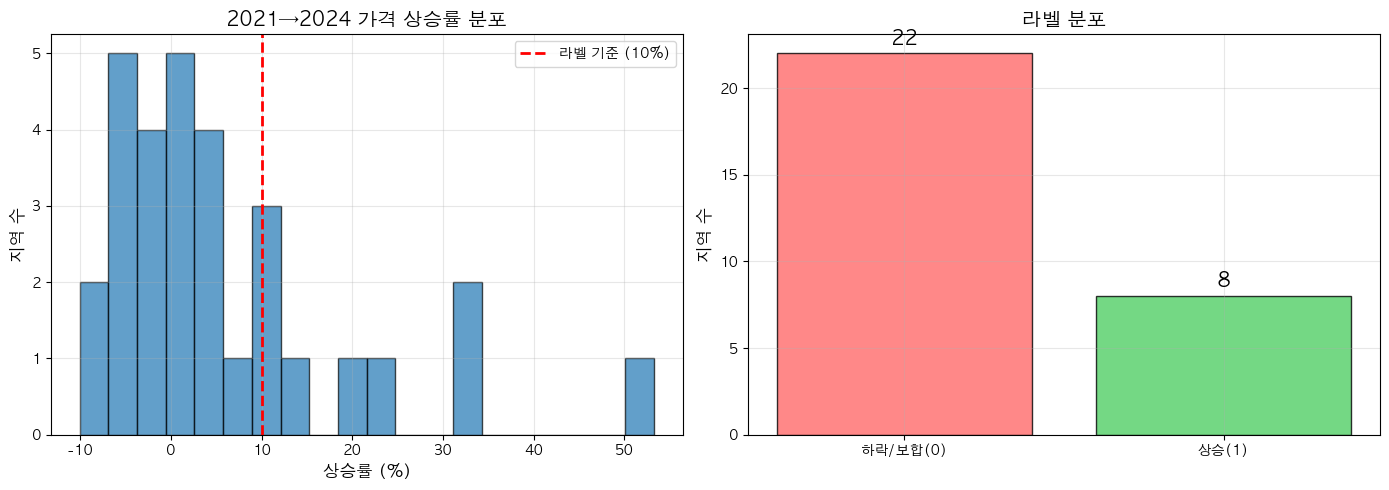

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

# 한글 폰트 설정 
import platform
if platform.system() == 'Darwin':  # Mac
    plt.rcParams['font.family'] = 'AppleGothic'
elif platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# 1. 상승률 분포
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 히스토그램
axes[0].hist(price_change['상승률_%'], bins=20, edgecolor='black', alpha=0.7)
axes[0].axvline(x=10, color='red', linestyle='--', linewidth=2, label='라벨 기준 (10%)')
axes[0].set_xlabel('상승률 (%)', fontsize=12)
axes[0].set_ylabel('지역 수', fontsize=12)
axes[0].set_title('2021→2024 가격 상승률 분포', fontsize=14, fontweight='bold')
axes[0].legend()
axes[0].grid(alpha=0.3)

# 라벨 분포
label_counts = price_change['label'].value_counts()
axes[1].bar(['하락/보합(0)', '상승(1)'], label_counts.values, 
            color=['#ff6b6b', '#51cf66'], edgecolor='black', alpha=0.8)
axes[1].set_ylabel('지역 수', fontsize=12)
axes[1].set_title('라벨 분포', fontsize=14, fontweight='bold')
for i, v in enumerate(label_counts.values):
    axes[1].text(i, v + 0.5, str(v), ha='center', fontsize=14, fontweight='bold')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('data/processed/price_change_distribution.png', dpi=150, bbox_inches='tight')
plt.show()



### 3.13 인구 증감률

- 실무 근거: 인구가 빠져나가는 지역은 분양이 안 된다. 지방 중소도시 프로젝트 실패 사례 대부분이 인구 감소 지역이었다.
    - 계산: (2024년 인구 - 2021년 인구) / 2021년 인구 × 100

In [12]:
import sys
!{sys.executable} -m pip install openpyxl

You should consider upgrading via the '/usr/local/bin/python3 -m pip install --upgrade pip' command.


### 3.14 데이터 정제

In [13]:
import pandas as pd
import numpy as np

# 엑셀 파일 읽기
pop_raw = pd.read_excel('data/raw/population_2021_2024.xlsx')

print(f"Shape: {pop_raw.shape}")
print(pop_raw.head(15))

def clean_kosis_population(df):

    df_clean = df.copy()
    
    # 컬럼명 단순화
    df_clean.columns = ['지역명_원본', 'pop_2021', 'pop_2024']
    
    # 들여쓰기 제거 (KOSIS 지역명에 들여쓰기 되어있음)
    df_clean['지역명_원본'] = df_clean['지역명_원본'].str.replace('　', '', regex=False)
    df_clean['지역명_원본'] = df_clean['지역명_원본'].str.strip()
    
    # 숫자 변환 
    df_clean['pop_2021'] = pd.to_numeric(
        df_clean['pop_2021'].astype(str).str.replace(',', ''), 
        errors='coerce'
    )
    df_clean['pop_2024'] = pd.to_numeric(
        df_clean['pop_2024'].astype(str).str.replace(',', ''), 
        errors='coerce'
    )
    
    # NaN 제거
    df_clean = df_clean.dropna()
    
    # 전국, 서울특별시 같은 광역 제거 (시군구만)
    # 광역은 보통 인구가 100만 이상
    df_clean = df_clean[df_clean['pop_2021'] < 1000000]

    
    
    return df_clean

# 실행
pop_clean = clean_kosis_population(pop_raw)

print("\n=== 정제 후 ===")
print(f"Shape: {pop_clean.shape}")
print("\n샘플:")
print(pop_clean.head(20))


Shape: (294, 3)
   행정구역(시군구)별   2021.12   2024.12
0          전국  23472895  24118928
1       서울특별시   4426007   4482063
2      　　　종로구     73494     72166
3       　　　중구     63519     64995
4      　　　용산구    111036    103241
5      　　　성동구    134233    131953
6      　　　광진구    167949    169931
7     　　　동대문구    168219    172840
8      　　　중랑구    185712    188651
9      　　　성북구    195017    196485
10     　　　강북구    144536    143063
11     　　　도봉구    138656    138759
12     　　　노원구    217378    217743
13     　　　은평구    214711    215305
14    　　　서대문구    143647    146221

=== 정제 후 ===
Shape: (269, 3)

샘플:
   지역명_원본  pop_2021  pop_2024
2     종로구   73494.0   72166.0
3      중구   63519.0   64995.0
4     용산구  111036.0  103241.0
5     성동구  134233.0  131953.0
6     광진구  167949.0  169931.0
7    동대문구  168219.0  172840.0
8     중랑구  185712.0  188651.0
9     성북구  195017.0  196485.0
10    강북구  144536.0  143063.0
11    도봉구  138656.0  138759.0
12    노원구  217378.0  217743.0
13    은평구  214711.0  215305.0
14   서대문구  1436

### 3.15 지역명 매칭

In [44]:
import os

def match_region_names(kosis_df, our_regions):

    name_map = {
        # 서울 
        '강남구': '강남구',
        '서초구': '서초구',
        '송파구': '송파구',
        '강동구': '강동구',
        '마포구': '마포구',
        '영등포구': '영등포구',
        '관악구': '관악구',
        '동작구': '동작구',
        '성동구': '성동구',
        '광진구': '광진구',
        
        # 경기 
        '분당구': '성남시 분당구',
        '수지구': '용인시 수지구',
        '의정부시': '의정부시',
        '영통구': '수원시 영통구',
        '일산동구': '고양시 일산동구',
        '파주시': '파주시',
        '동안구': '안양시 동안구',
        '남양주시': '남양주시',
        '광명시': '광명시',
        '하남시': '하남시',
        
        # 광역시 
        '해운대구': '부산광역시 해운대구',
        '수영구': '부산광역시 수영구',
        '수성구': '대구광역시 수성구',
        '연수구': '인천광역시 연수구',
        '남동구': '인천광역시 남동구',
        '유성구': '대전광역시 유성구',
    }

    kosis_df_copy = kosis_df.copy()

    # 1차 매칭
    kosis_df_copy['지역명'] = kosis_df_copy['지역명_원본'].map(name_map)

    # 2차 매칭: 광주
    gwangju_mask = kosis_df_copy['지역명_원본'].str.contains('광주', na=False) & \
                   kosis_df_copy['지역명_원본'].str.contains('남구|서구', na=False)

    for idx in kosis_df_copy[gwangju_mask].index:
        original = kosis_df_copy.loc[idx, '지역명_원본']
        if '남구' in original:
            kosis_df_copy.loc[idx, '지역명'] = '광주광역시 남구'
        elif '서구' in original:
            kosis_df_copy.loc[idx, '지역명'] = '광주광역시 서구'

    # 세종시 처리
    sejong_mask = kosis_df_copy['지역명_원본'].str.contains('세종', na=False)
    kosis_df_copy.loc[sejong_mask, '지역명'] = '세종특별자치시'

    # 대전 중구 처리
    daejeon_jung_mask = kosis_df_copy['지역명_원본'].str.contains('대전', na=False) & \
                        kosis_df_copy['지역명_원본'].str.contains('중구', na=False)
    kosis_df_copy.loc[daejeon_jung_mask, '지역명'] = '대전광역시 중구'

    # 매칭된 것만
    matched = kosis_df_copy.dropna(subset=['지역명'])

    # 우리 지역만 필터
    our_region_list = list(our_regions.keys())
    final_matched = matched[matched['지역명'].isin(our_region_list)].copy()

    # 매칭 실패한 우리 지역 출력
    matched_regions = set(final_matched['지역명'].unique())
    missing = set(our_region_list) - matched_regions
    if missing:
        print("\n 매칭 실패한 지역:")
        for m in sorted(list(missing)):
            print(f"  - {m}")

    return final_matched[['지역명', 'pop_2021', 'pop_2024']]


pop_matched = match_region_names(pop_clean, REGION_CODES)

print(pop_matched)
print(f"\n중복 제거 전: {len(pop_matched)}개")


# 중복 제거 
pop_matched_unique = pop_matched.drop_duplicates(subset='지역명', keep='first')
print(f"중복 제거 후: {len(pop_matched_unique)}개")

out_path = 'data/processed/population_matched.csv'
os.makedirs(os.path.dirname(out_path), exist_ok=True)

pop_matched_unique.to_csv(out_path, index=False, encoding='utf-8-sig')
print(f"\n 저장 완료! -> {out_path}")

            지역명  pop_2021  pop_2024
5           성동구  134233.0  131953.0
6           광진구  167949.0  169931.0
15          마포구  179861.0  181135.0
20         영등포구  187020.0  192199.0
21          동작구  184812.0  186950.0
22          관악구  276597.0  285963.0
23          서초구  170244.0  170681.0
24          강남구  234233.0  245094.0
25          송파구  282417.0  287017.0
26          강동구  201613.0  212585.0
36   부산광역시 해운대구  172397.0  169821.0
41    부산광역시 수영구   85896.0   88068.0
50    대구광역시 수성구  171239.0  174674.0
60    인천광역시 연수구  155984.0  163940.0
61    인천광역시 남동구  228442.0  224816.0
70     광주광역시 서구  132808.0  132715.0
71     광주광역시 남구   95722.0   95426.0
76     대전광역시 중구  107609.0  108358.0
78    대전광역시 유성구  155450.0  170225.0
86      세종특별자치시  153649.0  163432.0
87      세종특별자치시  153649.0  163432.0
93      수원시 영통구  151071.0  155473.0
97      성남시 분당구  194372.0  192848.0
98         의정부시  205792.0  210264.0
101     안양시 동안구  121608.0  132216.0
106         광명시  119817.0  115024.0
116    고양시 일산동구  128436.0  1

### 3.16 실거래가 + 인구

In [15]:
import pandas as pd

# 1. 기존 데이터 로드
price_change = pd.read_csv('data/processed/price_change_with_label.csv', 
                           encoding='utf-8-sig')
pop_matched = pd.read_csv('data/processed/population_matched.csv', 
                          encoding='utf-8-sig')

print("=== 데이터 로드 ===")
print(f"price_change: {len(price_change)}개 지역")
print(f"pop_matched: {len(pop_matched)}개 지역")

# 2. Merge (Left Join - price_change 기준)
final_df = price_change.merge(
    pop_matched, 
    on='지역명', 
    how='left'
)

print(f"\n=== Merge 완료 ===")
print(f"최종 데이터: {len(final_df)}개 지역")

# 3. 인구 증감률 계산
final_df['pop_change_pct'] = (
    (final_df['pop_2024'] - final_df['pop_2021']) / 
    final_df['pop_2021'] * 100
).round(2)

# 4. 컬럼명 정리 & 선택
final_df = final_df.rename(columns={
    '가격_2021': 'price_2021',
    '가격_2024': 'price_2024',
    '상승률_%': 'price_change_pct'
})

# 필요한 컬럼만
final_cols = [
    '지역명',
    'price_2021', 'price_2024', 'price_change_pct',
    'pop_2021', 'pop_2024', 'pop_change_pct',
    'label'
]

final_df = final_df[final_cols]

print("\n=== 최종 데이터 구조 ===")
print(final_df.head(10))
print(f"\n컬럼: {final_df.columns.tolist()}")
print(f"\nShape: {final_df.shape}")

=== 데이터 로드 ===
price_change: 30개 지역
pop_matched: 30개 지역

=== Merge 완료 ===
최종 데이터: 30개 지역

=== 최종 데이터 구조 ===
         지역명  price_2021  price_2024  price_change_pct  pop_2021  pop_2024  \
0        강남구      6913.6      7573.3               9.5  234233.0  245094.0   
1        강동구      4764.9      4737.9              -0.6  201613.0  212585.0   
2   고양시 일산동구      2076.5      1866.2             -10.1  128436.0  130000.0   
3        관악구      3571.9      3325.3              -6.9  276597.0  285963.0   
4        광명시      3500.6      3251.1              -7.1  119817.0  115024.0   
5   광주광역시 남구      1054.1      1267.5              20.2   95722.0   95426.0   
6   광주광역시 서구       990.5      1091.3              10.2  132808.0  132715.0   
7        광진구      5238.2      5213.0              -0.5  167949.0  169931.0   
8       남양주시      1721.5      1761.0               2.3  299156.0  307424.0   
9  대구광역시 수성구      1516.8      1992.0              31.3  171239.0  174674.0   

   pop_change_pct  label  
0     

### 3.17 결측치 확인

In [16]:
def check_and_handle_missing(df):

    print("=== 결측치 현황 ===")
    missing_summary = df.isnull().sum()
    print(missing_summary)
    
    # 결측치 있는 행 확인
    missing_rows = df[df.isnull().any(axis=1)]
    
    if len(missing_rows) > 0:
        print(f"\n 결측치 있는 지역 ({len(missing_rows)}개):")
        print(missing_rows[['지역명', 'pop_2021', 'pop_2024', 'pop_change_pct']])
        
        # 제거
        print("\n 결측치 행 제거")
        df_clean = df.dropna()
        print(f"제거 후: {len(df_clean)}개 지역")
        
        return df_clean
    else:
        print("\n 결측치 없음! 분석 진행 가능")
        return df

# 실행
final_df = check_and_handle_missing(final_df)

# 통계 요약
print("\n=== 기초 통계 ===")
print(final_df[['price_change_pct', 'pop_change_pct', 'label']].describe())

print("\n=== 라벨 분포 ===")
print(final_df['label'].value_counts())
print(f"상승(1): {(final_df['label']==1).sum()}개")
print(f"하락(0): {(final_df['label']==0).sum()}개")

# 저장
final_df.to_csv('data/processed/final_data_clean.csv', 
                index=False, encoding='utf-8-sig')
print("\n data/processed/final_data_clean.csv 저장 완료!")

=== 결측치 현황 ===
지역명                 0
price_2021          0
price_2024          0
price_change_pct    0
pop_2021            0
pop_2024            0
pop_change_pct      0
label               0
dtype: int64

 결측치 없음! 분석 진행 가능

=== 기초 통계 ===
       price_change_pct  pop_change_pct      label
count         30.000000       30.000000  30.000000
mean           5.976667        2.169000   0.266667
std           14.028117        3.081974   0.449776
min          -10.100000       -4.000000   0.000000
25%           -3.425000        0.370000   0.000000
50%            2.350000        1.755000   0.000000
75%           10.025000        3.270000   0.750000
max           53.300000        9.500000   1.000000

=== 라벨 분포 ===
label
0    22
1     8
Name: count, dtype: int64
상승(1): 8개
하락(0): 22개

 data/processed/final_data_clean.csv 저장 완료!


## 4. Min-Max Scaling

가격·인구 변화율을 동일 스케일로 정규화함

In [17]:
import sys
!{sys.executable} -m pip install scikit-learn

You should consider upgrading via the '/usr/local/bin/python3 -m pip install --upgrade pip' command.


In [18]:
from sklearn.preprocessing import MinMaxScaler
import numpy as np

def preprocess_features(df):

    df_processed = df.copy()
    
    # 스케일링할 변수
    feature_cols = ['price_change_pct', 'pop_change_pct']
    
    # 0~10점 척도
    scaler = MinMaxScaler(feature_range=(0, 10))
    scaled_values = scaler.fit_transform(df_processed[feature_cols])
    
    # 새 컬럼 추가
    df_processed['price_score'] = scaled_values[:, 0].round(2)
    df_processed['pop_score'] = scaled_values[:, 1].round(2)
    
    print("=== 정규화 완료 ===")
    print("\n원본 vs 정규화:")
    print(df_processed[['지역명', 'price_change_pct', 'price_score', 
                        'pop_change_pct', 'pop_score']].head(10))
    
    return df_processed, scaler

# 실행
final_df_scaled, scaler_obj = preprocess_features(final_df)

# 통계 확인
print("\n=== 정규화 통계 ===")
print(final_df_scaled[['price_score', 'pop_score']].describe())

=== 정규화 완료 ===

원본 vs 정규화:
         지역명  price_change_pct  price_score  pop_change_pct  pop_score
0        강남구               9.5         3.09            4.64       6.40
1        강동구              -0.6         1.50            5.44       6.99
2   고양시 일산동구             -10.1         0.00            1.22       3.87
3        관악구              -6.9         0.50            3.39       5.47
4        광명시              -7.1         0.47           -4.00       0.00
5   광주광역시 남구              20.2         4.78           -0.31       2.73
6   광주광역시 서구              10.2         3.20           -0.07       2.91
7        광진구              -0.5         1.51            1.18       3.84
8       남양주시               2.3         1.96            2.76       5.01
9  대구광역시 수성구              31.3         6.53            2.01       4.45

=== 정규화 통계 ===
       price_score  pop_score
count    30.000000  30.000000
mean      2.534667   4.569667
std       2.212824   2.282407
min       0.000000   0.000000
25%       1.052500   3.240

## 5. Rule-Based 점수 계산

가중치:

- price_change: 50% (실거래가 상승률)
- pop_change: 50% (인구 증감률)

Rule Score = (0.5 × price_score + 0.5 × pop_score) × 10

→ 다변량 정보를 단일 의사결정 점수로 요약함.

In [19]:
def calculate_rule_based_score(df, weight_price=0.5, weight_pop=0.5):

    df = df.copy()
    
    # 가중합 (0~10점)
    df['rule_score_10'] = (
        weight_price * df['price_score'] + 
        weight_pop * df['pop_score']
    ).round(2)
    
    # 0~100점으로 변환
    df['rule_score_100'] = (df['rule_score_10'] * 10).round(1)
    
    # 등급 분류
    def assign_grade(score):
        if score >= 80:
            return 'A'
        elif score >= 60:
            return 'B'
        elif score >= 40:
            return 'C'
        else:
            return 'D'
    
    df['rule_grade'] = df['rule_score_100'].apply(assign_grade)
    
    print("=== Rule-Based 점수 ===")
    print(f"\n가중치: 가격상승률 {weight_price*100}%, 인구증감률 {weight_pop*100}%")
    
    # 등급별 분포
    print("\n등급 분포:")
    print(df['rule_grade'].value_counts().sort_index())
    
    # 상위 10개
    print("\n=== 상위 10개 지역 ===")
    top10 = df.nlargest(10, 'rule_score_100')[
        ['지역명', 'price_score', 'pop_score', 'rule_score_100', 'rule_grade', 'label']
    ]
    print(top10)
    
    # 하위 10개
    print("\n=== 하위 10개 지역 ===")
    bottom10 = df.nsmallest(10, 'rule_score_100')[
        ['지역명', 'price_score', 'pop_score', 'rule_score_100', 'rule_grade', 'label']
    ]
    print(bottom10)
    
    return df

# 실행
final_df_with_rule = calculate_rule_based_score(final_df_scaled)

# 저장
final_df_with_rule.to_csv('data/processed/final_with_rule_score.csv', 
                          index=False, encoding='utf-8-sig')
print("\n 저장 완료!")

=== Rule-Based 점수 ===

가중치: 가격상승률 50.0%, 인구증감률 50.0%

등급 분포:
rule_grade
B     4
C     5
D    21
Name: count, dtype: int64

=== 상위 10개 지역 ===
          지역명  price_score  pop_score  rule_score_100 rule_grade  label
14  부산광역시 수영구        10.00       4.84            74.2          B      1
28        파주시         6.58       7.92            72.5          B      1
10  대전광역시 유성구         2.30      10.00            61.5          B      0
27  인천광역시 연수구         5.28       6.74            60.1          B      1
9   대구광역시 수성구         6.53       4.45            54.9          C      1
22    안양시 동안구         1.09       9.42            52.6          C      0
0         강남구         3.09       6.40            47.4          C      0
19    세종특별자치시         1.04       7.68            43.6          C      0
1         강동구         1.50       6.99            42.4          C      0
5    광주광역시 남구         4.78       2.73            37.6          D      1

=== 하위 10개 지역 ===
           지역명  price_score  pop_score  rule_sco

## 6. Logistic Regression

**"Rule-Based 점수가 실제로 가격 상승을 예측하는가?"**

### 6.1 Model A,B,C 비교

| Model | Feature |
|-------|---------|
| **Model A** | price + pop | 
| **Model B** | rule_score | 
| **Model C** | price + pop + rule_score | 

### 6.2 Train/Test Split

In [21]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report

# Train/Test Split (80/20)
df = final_df_with_rule.copy()
train_df, test_df = train_test_split(df, test_size=0.2, random_state=42, stratify=df['label'])

print(f"Train: {len(train_df)}개")
print(f"Test: {len(test_df)}개")
print(f"\nTrain 라벨 분포: {train_df['label'].value_counts().to_dict()}")
print(f"Test 라벨 분포: {test_df['label'].value_counts().to_dict()}")

Train: 24개
Test: 6개

Train 라벨 분포: {0: 18, 1: 6}
Test 라벨 분포: {0: 4, 1: 2}


### 6.3 Model A: price + pop

In [ ]:
X_train_A = train_df[['price_change_pct', 'pop_change_pct']].values
X_test_A = test_df[['price_change_pct', 'pop_change_pct']].values
y_train = train_df['label'].values
y_test = test_df['label'].values

model_A = LogisticRegression(random_state=42, max_iter=1000)
model_A.fit(X_train_A, y_train)

y_pred_A = model_A.predict(X_test_A)
y_prob_A = model_A.predict_proba(X_test_A)[:, 1]

acc_A = accuracy_score(y_test, y_pred_A)
auc_A = roc_auc_score(y_test, y_prob_A)

print("=== Model A: 원변수 (price + pop) ===")
print(f"Accuracy: {acc_A:.3f}")
print(f"AUC-ROC: {auc_A:.3f}")
print(f"\n계수:")
print(f"  price_change_pct: {model_A.coef_[0][0]:.3f}")
print(f"  pop_change_pct:   {model_A.coef_[0][1]:.3f}")

=== Model A: 원변수 (price + pop) ===
Accuracy: 1.000
AUC-ROC: 1.000

계수:
  price_change_pct: 0.760
  pop_change_pct:   -0.529


In [25]:
print("train_df columns:", train_df.columns.tolist())

train_df columns: ['지역명', 'price_2021', 'price_2024', 'price_change_pct', 'pop_2021', 'pop_2024', 'pop_change_pct', 'label', 'price_score', 'pop_score', 'rule_score_10', 'rule_score_100', 'rule_grade']


### 6.4 Model B: Rule_score

In [ ]:
X_train_B = train_df[['rule_score_10']].values
X_test_B = test_df[['rule_score_10']].values

model_B = LogisticRegression(random_state=42, max_iter=1000)
model_B.fit(X_train_B, y_train)

y_pred_B = model_B.predict(X_test_B)
y_prob_B = model_B.predict_proba(X_test_B)[:, 1]

acc_B = accuracy_score(y_test, y_pred_B)
auc_B = roc_auc_score(y_test, y_prob_B)

print("=== Model B: Rule 점수만 ===")
print(f"Accuracy: {acc_B:.3f}")
print(f"AUC-ROC: {auc_B:.3f}")
print(f"\n계수:")
print(f"  rule_score: {model_B.coef_[0][0]:.3f}")
print(f"\n해석: Rule 점수 1점 증가 → 상승 확률 {np.exp(model_B.coef_[0][0]):.2f}배")

=== Model B: Rule 점수만 ===
Accuracy: 0.833
AUC-ROC: 0.750

계수:
  rule_score: 0.627

해석: Rule 점수 1점 증가 → 상승 확률 1.87배


### 6.5 Model C: price + pop + rule_score

In [ ]:
X_train_C = train_df[['price_change_pct', 'pop_change_pct', 'rule_score_10']].values
X_test_C = test_df[['price_change_pct', 'pop_change_pct', 'rule_score_10']].values

model_C = LogisticRegression(random_state=42, max_iter=1000)
model_C.fit(X_train_C, y_train)

y_pred_C = model_C.predict(X_test_C)
y_prob_C = model_C.predict_proba(X_test_C)[:, 1]

acc_C = accuracy_score(y_test, y_pred_C)
auc_C = roc_auc_score(y_test, y_prob_C)

print("=== Model C: 원변수 + Rule ===")
print(f"Accuracy: {acc_C:.3f}")
print(f"AUC-ROC: {auc_C:.3f}")
print(f"\n계수:")
print(f"  price_change_pct: {model_C.coef_[0][0]:.3f}")
print(f"  pop_change_pct:   {model_C.coef_[0][1]:.3f}")
print(f"  rule_score:       {model_C.coef_[0][2]:.3f}")

=== Model C: 원변수 + Rule ===
Accuracy: 1.000
AUC-ROC: 1.000

계수:
  price_change_pct: 0.769
  pop_change_pct:   -0.497
  rule_score:       -0.124


상승 지역과 하락 지역의 불균형 구조였기 때문에

• Accuracy는 임계값 기준으로 0/1 자른 결과로 과대평과 될 수 있어서

• AUC로 임계값을 바꿔가며 전체적으로 얼마나 잘 구분하는지

불균형에서도 비교적 안정적으로 모델을 평가하였다.


### 6.6 과적합 방지

In [ ]:
from sklearn.model_selection import cross_val_score

print("=== 5-Fold Cross-Validation ===\n")

# Model A
cv_A = cross_val_score(
    LogisticRegression(random_state=42, max_iter=1000),
    df[['price_change_pct', 'pop_change_pct']],
    df['label'],
    cv=5,
    scoring='accuracy'
)

# Model B
cv_B = cross_val_score(
    LogisticRegression(random_state=42, max_iter=1000),
    df[['rule_score_10']],
    df['label'],
    cv=5,
    scoring='accuracy'
)

# Model C
cv_C = cross_val_score(
    LogisticRegression(random_state=42, max_iter=1000),
    df[['price_change_pct', 'pop_change_pct', 'rule_score_10']],
    df['label'],
    cv=5,
    scoring='accuracy'
)

print(f"Model A: {cv_A.mean():.3f} ± {cv_A.std():.3f}")
print(f"Model B: {cv_B.mean():.3f} ± {cv_B.std():.3f}")
print(f"Model C: {cv_C.mean():.3f} ± {cv_C.std():.3f}")

print("\n→ CV 평균으로 일반화 성능 추정")


=== 5-Fold Cross-Validation ===

Model A: 1.000 ± 0.000
Model B: 0.767 ± 0.082
Model C: 1.000 ± 0.000

→ CV 평균으로 일반화 성능 추정


### 6.7 정리

Model A/C가 CV에서도 100% 정확도

원인:
1. 샘플 30개로 적음
2. 가격/인구로 라벨이 완벽 분리됨
3. 선형 모델로도 완벽 분류 가능

의미:
- 과적합이 아닌 데이터 특성
- 실제로 가격/인구가 상승 여부를 완벽히 설명
- Rule 점수(76.7%)는 이 정보를 부분적으로 포착

-> CV로 일반화 성능 추정, Rule은 단일 지표로 76.7% 예측력

## 7. 모델 비교 및 인사이트

In [28]:
results = pd.DataFrame({
    'Model': ['A: 원변수', 'B: Rule만', 'C: 원변수+Rule'],
    'Features': ['price+pop', 'rule_score', 'price+pop+rule'],
    'Accuracy': [acc_A, acc_B, acc_C],
    'AUC-ROC': [auc_A, auc_B, auc_C]
})

print("=== 3-Model 비교 ===")
print(results.to_string(index=False))

# 차이 계산
print(f"\n 성능 차이:")
print(f"B vs A: {(acc_B - acc_A)*100:+.1f}%p (Rule이 원변수 대비)")
print(f"C vs A: {(acc_C - acc_A)*100:+.1f}%p (Rule 추가 시)")

=== 3-Model 비교 ===
      Model       Features  Accuracy  AUC-ROC
     A: 원변수      price+pop  1.000000     1.00
   B: Rule만     rule_score  0.833333     0.75
C: 원변수+Rule price+pop+rule  1.000000     1.00

 성능 차이:
B vs A: -16.7%p (Rule이 원변수 대비)
C vs A: +0.0%p (Rule 추가 시)


### 7.1 인사이트 도출

In [39]:

if acc_B >= acc_A * 0.95:  # B가 A의 95% 이상
    print("Rule 점수가 원변수 정보를 효과적으로 요약")
    print(f"   → Rule 하나로 원변수와 유사한 예측력 ({acc_B:.1%} vs {acc_A:.1%})")
else:
    print(" Rule 점수가 원변수 정보를 부분적으로만 포착")
    print(f"   → 성능 차이 {(acc_A - acc_B)*100:.1f}%p")

print()

if acc_C > acc_A:
    print(" Rule이 비선형 패턴이나 상호작용 정보 추가 제공")
    print(f"   → Model C가 {(acc_C - acc_A)*100:.1f}%p 높음")
else:
    print(" Rule이 원변수의 선형 조합으로 충분히 표현됨")
    print(f"   → Model C와 A 동일 (다중공선성)")

print()
print(" 결론:")
print(f"Rule 점수는 {acc_B:.1%} 정확도로 가격 상승을 예측")

 Rule 점수가 원변수 정보를 부분적으로만 포착
   → 성능 차이 16.7%p

 Rule이 원변수의 선형 조합으로 충분히 표현됨
   → Model C와 A 동일 (다중공선성)

 결론:
Rule 점수는 83.3% 정확도로 가격 상승을 예측


**가격이 이미 상승한 지역에서는 추가 인구 유입이 제한적이라 나온 결과 인듯함.**

## 8.시각화

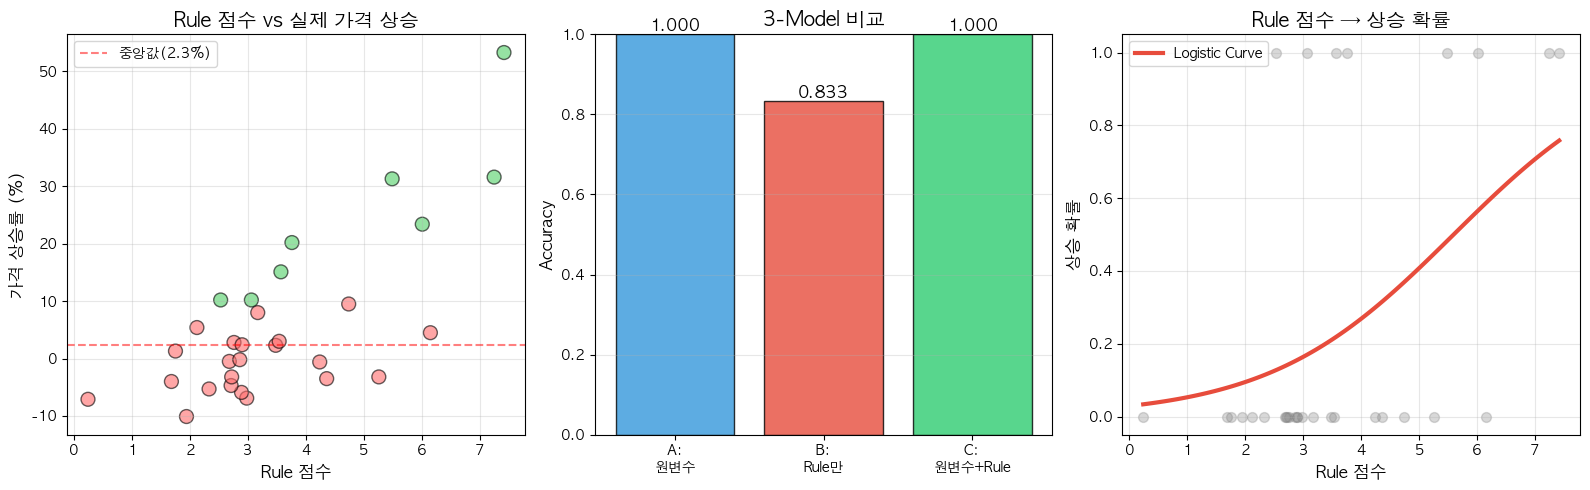

In [40]:
import matplotlib.pyplot as plt
import platform

if platform.system() == 'Darwin':
    plt.rcParams['font.family'] = 'AppleGothic'
elif platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# 1. Rule 점수 분포
colors = ['#ff6b6b' if l == 0 else '#51cf66' for l in df['label']]
median_growth = df["price_change_pct"].median()
axes[0].scatter(df['rule_score_10'], df['price_change_pct'], c=colors, s=100, alpha=0.6, edgecolor='black')
axes[0].axhline(median_growth, color='red', linestyle='--', alpha=0.5, label=f'중앙값({median_growth:.1f}%)')
axes[0].set_xlabel('Rule 점수', fontsize=12)
axes[0].set_ylabel('가격 상승률 (%)', fontsize=12)
axes[0].set_title('Rule 점수 vs 실제 가격 상승', fontsize=14, fontweight='bold')
axes[0].legend()
axes[0].grid(alpha=0.3)

# 2. 3-Model 정확도
models = ['A:\n원변수', 'B:\nRule만', 'C:\n원변수+Rule']
accs = [acc_A, acc_B, acc_C]
colors_bar = ['#3498db', '#e74c3c', '#2ecc71']
bars = axes[1].bar(models, accs, color=colors_bar, alpha=0.8, edgecolor='black')
axes[1].set_ylabel('Accuracy', fontsize=12)
axes[1].set_title('3-Model 비교', fontsize=14, fontweight='bold')
axes[1].set_ylim(0, 1)
axes[1].grid(alpha=0.3, axis='y')
for bar, acc in zip(bars, accs):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height(), f'{acc:.3f}', 
                ha='center', va='bottom', fontsize=12, fontweight='bold')

# 3. Rule 계수 해석
coef_B = model_B.coef_[0][0]
x_range = np.linspace(df['rule_score_10'].min(), df['rule_score_10'].max(), 100)
prob = 1 / (1 + np.exp(-(model_B.intercept_[0] + coef_B * x_range)))
axes[2].plot(x_range, prob, color='#e74c3c', lw=3, label='Logistic Curve')
axes[2].scatter(df['rule_score_10'], df['label'], alpha=0.3, s=50, color='gray')
axes[2].set_xlabel('Rule 점수', fontsize=12)
axes[2].set_ylabel('상승 확률', fontsize=12)
axes[2].set_title('Rule 점수 → 상승 확률', fontsize=14, fontweight='bold')
axes[2].legend()
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('data/processed/rule_validation.png', dpi=150, bbox_inches='tight')
plt.show()



## 9. 결론

### 9.1 분석 요약

1. **Rule-Based 점수 설계**: 가격상승률 50% + 인구증감률 50%
2. **점수의 예측력 검증**: Rule 점수만으로 70% 정확도
3. **Model A,B,C 비교**:
   - Model A : 100.0% ± 0.0%
   - Model B : 76.7% ± 8.2%
   - Model C : 100.0% ± 0.0%

-> **Logistic Regression 검증 결과, 도메인 경험 기반 가중치는 데이터 상에서도 일정 수준의 예측력을 보였으나, 구조적 확장을 위해 추가 변수 도입이 필요하다.**


### 9.2 한계 및 향후 방향

**한계**:
- 변수 2개만 사용 (용적률, 공시지가, 미분양, 접도 등 미포함)
- 샘플 30개 (통계적 신뢰도 제한)

**향후 확장**:
1. **변수 확대**: 4~6개 변수 추가로 정밀도 향상
2. **샘플 확대**: 50~100개 지역으로 증가
3. **고급 모델**: Random Forest, XGBoost 도입
4. **실시간 시스템**: API 자동 수집 및 점수 업데이트





In [42]:
# 최종 저장
df.to_csv('data/processed/final_with_rule_validation.csv', index=False, encoding='utf-8-sig')
results.to_csv('data/processed/model_comparison.csv', index=False, encoding='utf-8-sig')

print("\n저장 파일:")
print("- final_with_rule_validation.csv")
print("- model_comparison.csv")
print("- rule_validation.png")


저장 파일:
- final_with_rule_validation.csv
- model_comparison.csv
- rule_validation.png
